# Analyse des Avis et Alertes ANSSI avec Enrichissement des CVE

**TD Final – SUPDEVINCI 2026**

Ce notebook charge les données consolidées (avis/alertes ANSSI + CVE enrichies
via MITRE et EPSS), explore le jeu de données, produit des visualisations, puis
applique et valide un modèle de Machine Learning supervisé et un modèle non
supervisé.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Chargement du fichier CSV produit

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data/vulnerabilites_anssi.csv").exists():
    PROJECT_ROOT = Path.cwd().parent

csv_path = PROJECT_ROOT / "data/vulnerabilites_anssi.csv"
df = pd.read_csv(csv_path, parse_dates=["date_publication"])
df.shape


(284639, 15)

In [3]:
df.head(10)

,id_anssi,titre_anssi,type_bulletin,date_publication,cve,cvss_score,base_severity,cwe,cwe_desc,epss_score,lien_anssi,description,editeur,produit,versions_affectees
0,CERTFR-2023-AVI-0001,Vulnérabilité dans Apache Tomcat,Avis,2023-01-04 00:00:00+00:00,CVE-2022-45143,NaN,NaN,CWE-116,CWE-116 Improper Encoding or Escaping of Output,0.00950,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,The JsonErrorReportValve in Apache Tomcat 8.5....,Apache Software Foundation,Apache Tomcat,"10.1.0-M1, 9.0.40, 8.5.83"
1,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-35845,7.6,HIGH,CWE-78,Execute unauthorized code or commands,0.03866,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,Multiple improper neutralization of special el...,Fortinet,FortiTester,"7.1.0, 7.0.0, 4.2.0, 4.1.0, 4.0.0, 3.9.0, 3.8...."
2,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-39947,8.6,HIGH,CWE-78,Execute unauthorized code or commands,0.01711,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,A improper neutralization of special elements ...,Fortinet,FortiADC,"7.0.0, 6.2.0, 6.1.0, 6.0.0, 5.4.0"
3,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-41336,6.6,MEDIUM,CWE-79,Execute unauthorized code or commands,0.00322,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,An improper neutralization of input during web...,Fortinet,FortiPortal,"6.0.0, 5.3.0, 5.2.0, 5.1.0, 5.0.0"
4,CERTFR-2023-AVI-0002,Multiples vulnérabilités dans les produits For...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-45857,6.0,MEDIUM,CWE-286,Improper access control,0.00348,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,An incorrect user management vulnerability [CW...,Fortinet,FortiManager,"7.0.0, 6.4.0, 6.2.0"
5,CERTFR-2023-AVI-0003,Multiples vulnérabilités dans les produits And...,Avis,2023-01-04 00:00:00+00:00,CVE-2021-35097,7.3,HIGH,Non disponible,Cryptographic issues in Content Protection,0.00032,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,Possible authentication bypass due to improper...,"Qualcomm, Inc.","Snapdragon Auto, Snapdragon Compute, Snapdrago...","AQT1000, AR8031, AR8035, CSRA6620, CSRA6640, C..."
6,CERTFR-2023-AVI-0003,Multiples vulnérabilités dans les produits And...,Avis,2023-01-04 00:00:00+00:00,CVE-2021-35113,7.3,HIGH,Non disponible,Cryptographic Issues in Key Provisioning,0.00032,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,Possible authentication bypass due to improper...,"Qualcomm, Inc.","Snapdragon Auto, Snapdragon Compute, Snapdrago...","AQT1000, CSRB31024, QCA6174A, QCA6310, QCA6335..."
7,CERTFR-2023-AVI-0003,Multiples vulnérabilités dans les produits And...,Avis,2023-01-04 00:00:00+00:00,CVE-2021-35134,8.4,HIGH,Non disponible,Incorrect Calculation of Buffer Size in Boot,0.00122,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,"Due to insufficient validation of ELF headers,...","Qualcomm, Inc.","Snapdragon Connectivity, Snapdragon Industrial...","QCA6391, QCM6490, QCS6490, QSM8350, SD 8 Gen1 ..."
8,CERTFR-2023-AVI-0003,Multiples vulnérabilités dans les produits And...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-20235,5.5,MEDIUM,Non disponible,Elevation of privilege,0.00037,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,"The PowerVR GPU kernel driver maintains an ""In...",NaN,Android,Android SoC
9,CERTFR-2023-AVI-0003,Multiples vulnérabilités dans les produits And...,Avis,2023-01-04 00:00:00+00:00,CVE-2022-20456,7.8,HIGH,Non disponible,Elevation of privilege,0.00025,https://www.cert.ssi.gouv.fr/avis/CERTFR-2023-...,"In AutomaticZenRule of AutomaticZenRule.java, ...",NaN,Android,Android-10 Android-11 Android-12 Android-12L A...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284639 entries, 0 to 284638
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id_anssi            284639 non-null  str                
 1   titre_anssi         284639 non-null  str                
 2   type_bulletin       284639 non-null  str                
 3   date_publication    284639 non-null  datetime64[us, UTC]
 4   cve                 284451 non-null  str                
 5   cvss_score          139040 non-null  float64            
 6   base_severity       139048 non-null  str                
 7   cwe                 284451 non-null  str                
 8   cwe_desc            277885 non-null  str                
 9   epss_score          283176 non-null  float64            
 10  lien_anssi          284639 non-null  str                
 11  description         284451 non-null  str                
 12  editeur             271610 

## 2. Exploration du DataFrame

On regarde la qualité des données (valeurs manquantes, doublons), la
répartition avis/alertes, le nombre de CVE uniques, etc.


In [5]:
print("Nombre de lignes :", len(df))
print("Nombre de bulletins ANSSI uniques :", df["id_anssi"].nunique())
print("Nombre de CVE uniques :", df["cve"].nunique())
print("Nombre d'éditeurs uniques :", df["editeur"].nunique())
print("Nombre de produits uniques :", df["produit"].nunique())


Nombre de lignes : 284639
Nombre de bulletins ANSSI uniques : 4103
Nombre de CVE uniques : 37287
Nombre d'éditeurs uniques : 720
Nombre de produits uniques : 6286


In [6]:
df.isna().mean().sort_values(ascending=False).to_frame("taux_valeurs_manquantes")


,taux_valeurs_manquantes
cvss_score,0.511522
base_severity,0.511494
versions_affectees,0.137581
editeur,0.045774
produit,0.026476
cwe_desc,0.023728
epss_score,0.005140
cve,0.000660
cwe,0.000660
description,0.000660


### 2.1 Filtrage des lignes sans score CVSS

51 % des CVE n'ont pas de score CVSS dans MITRE (CNA non renseigné ou score
porté uniquement par un ADP). On crée `df_cvss` - sous-ensemble des lignes
où `cvss_score` est disponible - utilisé pour toutes les visualisations et
analyses qui s'appuient sur cette colonne.

In [7]:
df_cvss = df.dropna(subset=["cvss_score"]).copy()
print(f"Lignes avec CVSS : {len(df_cvss):,} / {len(df):,} ({len(df_cvss)/len(df)*100:.1f} %)")
print(f"CVE uniques avec CVSS : {df_cvss['cve'].nunique():,}")
df_cvss["base_severity"].value_counts(dropna=False)

Lignes avec CVSS : 139,040 / 284,639 (48.8 %)
CVE uniques avec CVSS : 23,985


base_severity
HIGH        74879
MEDIUM      51683
CRITICAL     7144
LOW          5313
NONE           21
Name: count, dtype: int64

In [8]:
df["type_bulletin"].value_counts()


type_bulletin
Avis      283754
Alerte       885
Name: count, dtype: int64

In [9]:
df["base_severity"].value_counts(dropna=False)


base_severity
NaN               145591
HIGH               74879
MEDIUM             51683
CRITICAL            7144
LOW                 5313
NONE                  21
Non disponible         8
Name: count, dtype: int64

In [10]:
df[["cvss_score", "epss_score"]].describe()


,cvss_score,epss_score
count,139040.000000,283176.000000
mean,6.935793,0.014827
std,1.520004,0.086245
min,0.000000,0.000010
25%,5.600000,0.000190
50%,7.500000,0.000480
75%,7.800000,0.001460
max,10.000000,0.945170


## 3. Visualisations

### 3.1 Histogramme des scores CVSS

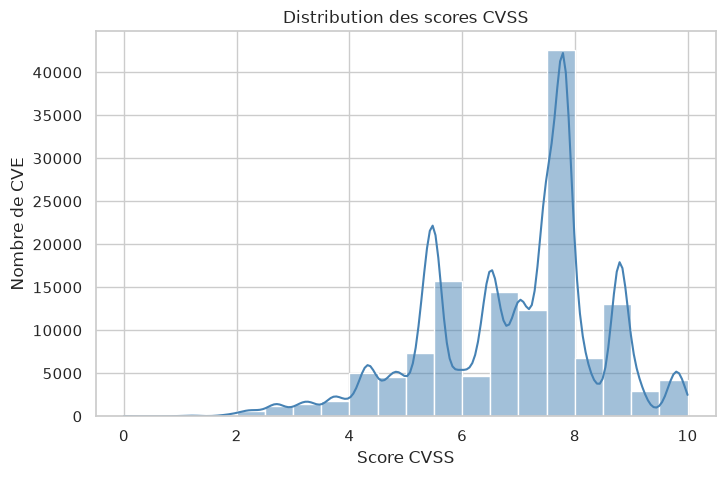

In [11]:
plt.figure(figsize=(8, 5))
sns.histplot(df["cvss_score"].dropna(), bins=20, kde=True, color="steelblue")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.show()


### 3.2 Répartition par niveau de sévérité (Base Severity)

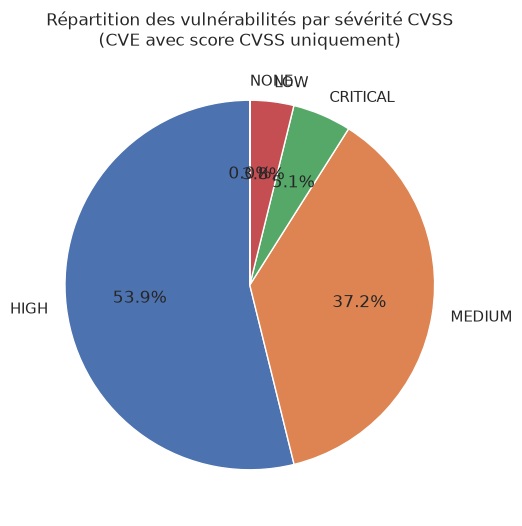

In [44]:
plt.figure(figsize=(6, 6))
df_cvss["base_severity"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Répartition des vulnérabilités par sévérité CVSS\n(CVE avec score CVSS uniquement)")
plt.show()

### 3.3 Diagramme circulaire des types de vulnérabilités (CWE)

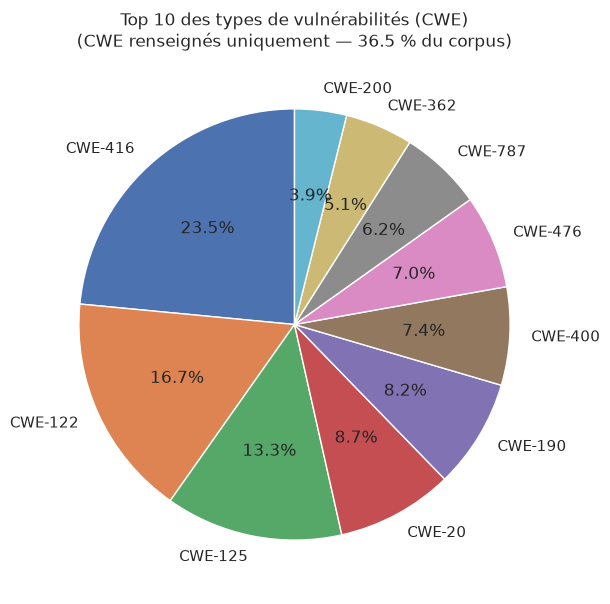

In [12]:
top_cwe = (
    df[df["cwe"].notna() & (df["cwe"] != "Non disponible")]
    ["cwe"].value_counts().head(10)
)
plt.figure(figsize=(7, 7))
top_cwe.plot.pie(autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Top 10 des types de vulnérabilités (CWE)\n(CWE renseignés uniquement - 36.5 % du corpus)")
plt.show()

### 3.4 Distribution des scores EPSS (probabilité d'exploitation)

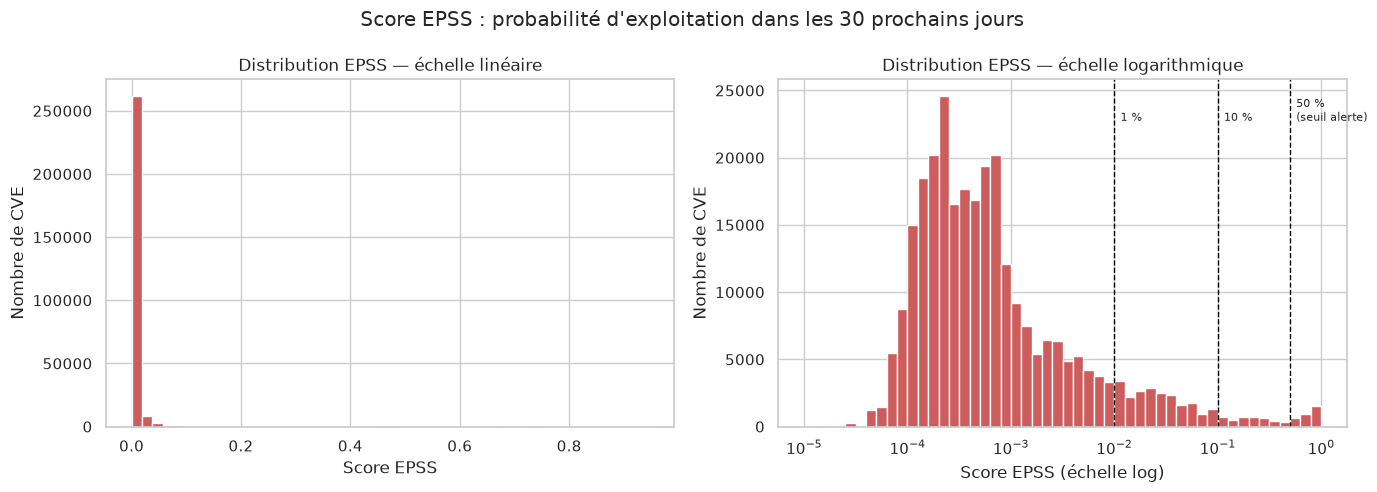

count    283176.000000
mean          0.014827
std           0.086245
min           0.000010
25%           0.000190
50%           0.000480
75%           0.001460
max           0.945170
Name: epss_score, dtype: float64

CVE avec EPSS ≥ 0.5 (seuil alerte) : 3,094 (1.09 %)
CVE avec EPSS ≥ 0.1               : 7,010 (2.48 %)


In [13]:
epss = df["epss_score"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Échelle linéaire
axes[0].hist(epss, bins=50, color="indianred")
axes[0].set_title("Distribution EPSS - échelle linéaire")
axes[0].set_xlabel("Score EPSS")
axes[0].set_ylabel("Nombre de CVE")

# Échelle log - axe X en valeurs réelles
axes[1].hist(epss.clip(lower=1e-5), bins=np.logspace(-5, 0, 51), color="indianred")
axes[1].set_xscale("log")
axes[1].set_title("Distribution EPSS - échelle logarithmique")
axes[1].set_xlabel("Score EPSS (échelle log)")
axes[1].set_ylabel("Nombre de CVE")
for seuil, label in [
    (0.01,  "1 %"),
    (0.1,   "10 %"),
    (0.5,   "50 %\n(seuil alerte)"),
]:
    axes[1].axvline(seuil, color="black", linestyle="--", linewidth=1)
    axes[1].text(seuil * 1.15, axes[1].get_ylim()[1] * 0.88, label, fontsize=8)

plt.suptitle("Score EPSS : probabilité d'exploitation dans les 30 prochains jours")
plt.tight_layout()
plt.show()

print(epss.describe())
print(f"\nCVE avec EPSS ≥ 0.5 (seuil alerte) : {(epss >= 0.5).sum():,} ({(epss >= 0.5).mean()*100:.2f} %)")
print(f"CVE avec EPSS ≥ 0.1               : {(epss >= 0.1).sum():,} ({(epss >= 0.1).mean()*100:.2f} %)")

### 3.5 Classement des éditeurs les plus affectés

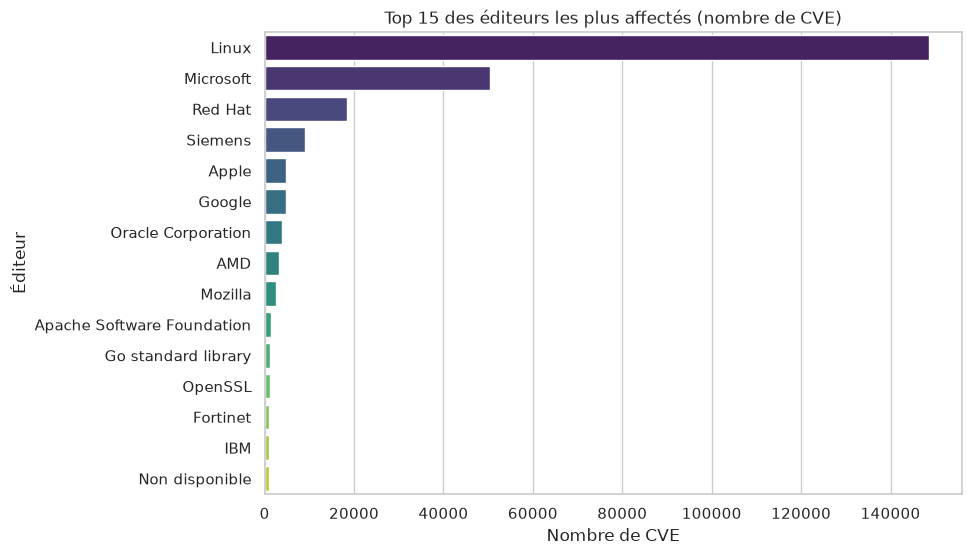

In [14]:
top_vendors = df["editeur"].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_vendors.values, y=top_vendors.index, hue=top_vendors.index, palette="viridis", legend=False)
plt.title("Top 15 des éditeurs les plus affectés (nombre de CVE)")
plt.xlabel("Nombre de CVE")
plt.ylabel("Éditeur")
plt.show()


### 3.6 Classement des produits les plus affectés

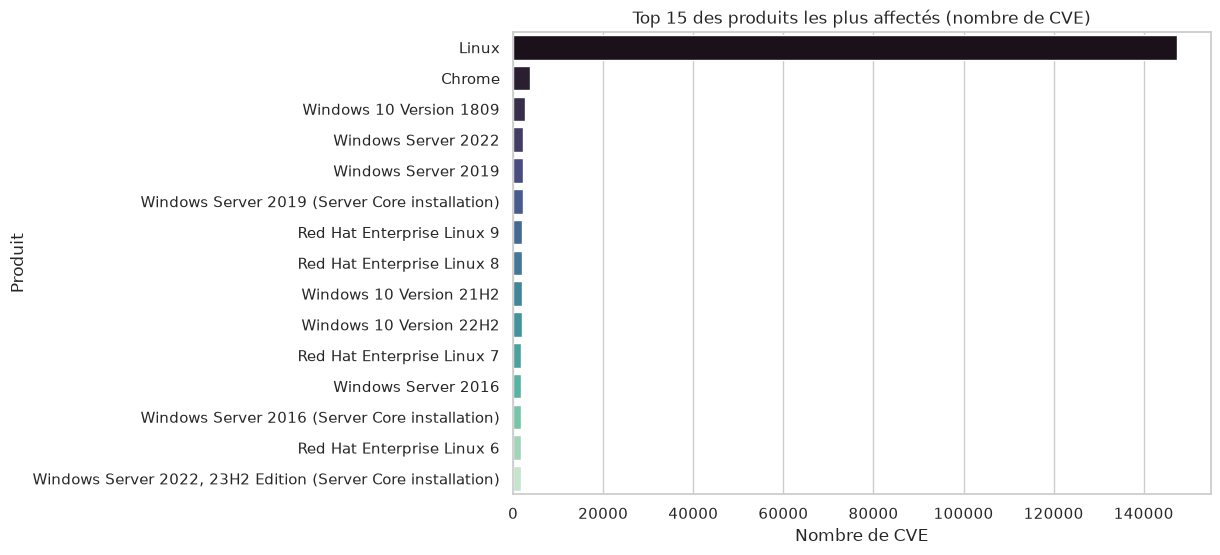

In [15]:
top_products = df["produit"].value_counts().head(15)
plt.figure(figsize=(9, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette="mako", legend=False)
plt.title("Top 15 des produits les plus affectés (nombre de CVE)")
plt.xlabel("Nombre de CVE")
plt.ylabel("Produit")
plt.show()


### 3.7 Heatmap de corrélation entre CVSS et EPSS

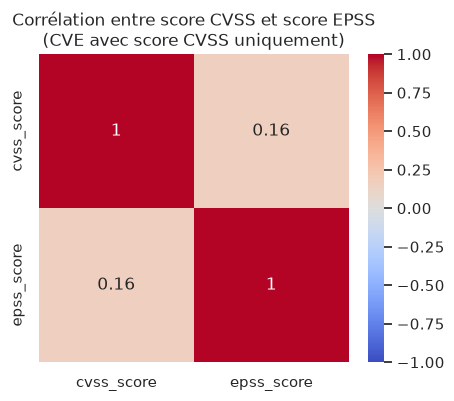

In [16]:
corr = df_cvss[["cvss_score", "epss_score"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre score CVSS et score EPSS\n(CVE avec score CVSS uniquement)")
plt.show()

### 3.8 Nuage de points Score CVSS vs Score EPSS

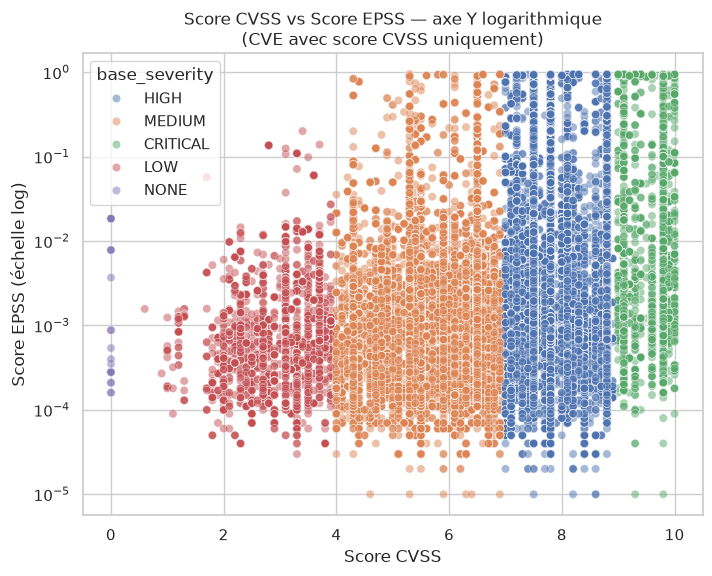

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_cvss, x="cvss_score", y="epss_score", hue="base_severity", alpha=0.5)
plt.yscale("log")
plt.title("Score CVSS vs Score EPSS - axe Y logarithmique\n(CVE avec score CVSS uniquement)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS (échelle log)")
plt.show()

### 3.9 Courbe cumulative des vulnérabilités détectées dans le temps

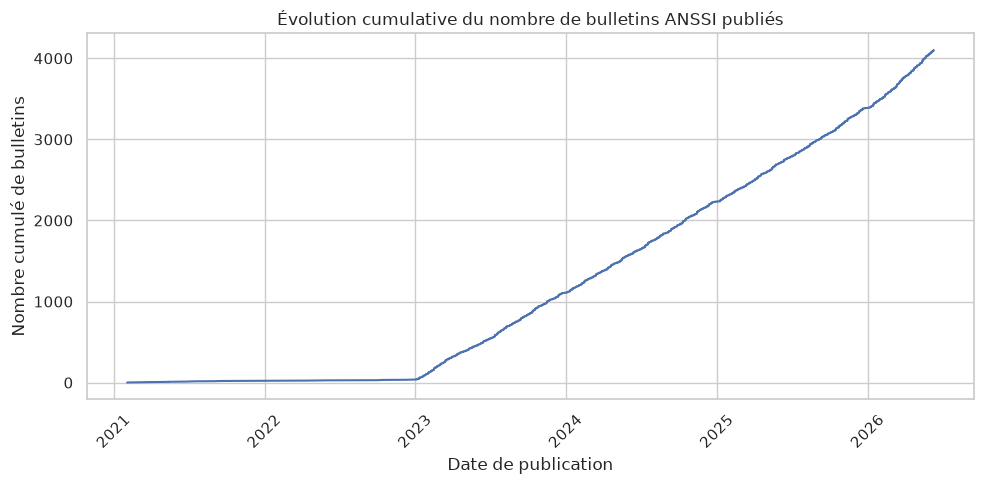

In [19]:
ts = (
    df.dropna(subset=["date_publication"])
    .drop_duplicates("id_anssi")
    .sort_values("date_publication")
)
ts["cumul"] = range(1, len(ts) + 1)

plt.figure(figsize=(10, 5))
plt.plot(ts["date_publication"], ts["cumul"])
plt.title("Évolution cumulative du nombre de bulletins ANSSI publiés")
plt.xlabel("Date de publication")
plt.ylabel("Nombre cumulé de bulletins")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 3.10 Boxplot des scores CVSS par éditeur (top 10)

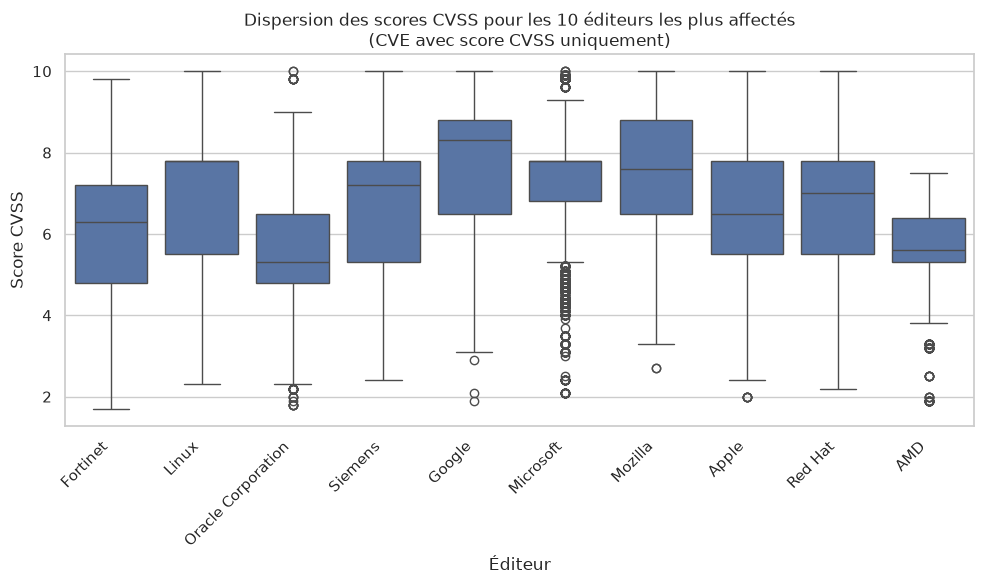

In [22]:
top10_vendors = df_cvss["editeur"].value_counts().head(10).index
subset = df_cvss[df_cvss["editeur"].isin(top10_vendors)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=subset, x="editeur", y="cvss_score")
plt.title("Dispersion des scores CVSS pour les 10 éditeurs les plus affectés\n(CVE avec score CVSS uniquement)")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Éditeur")
plt.ylabel("Score CVSS")
plt.tight_layout()
plt.show()

### 3.11 Nombre de vulnérabilités par éditeur, par type de bulletin

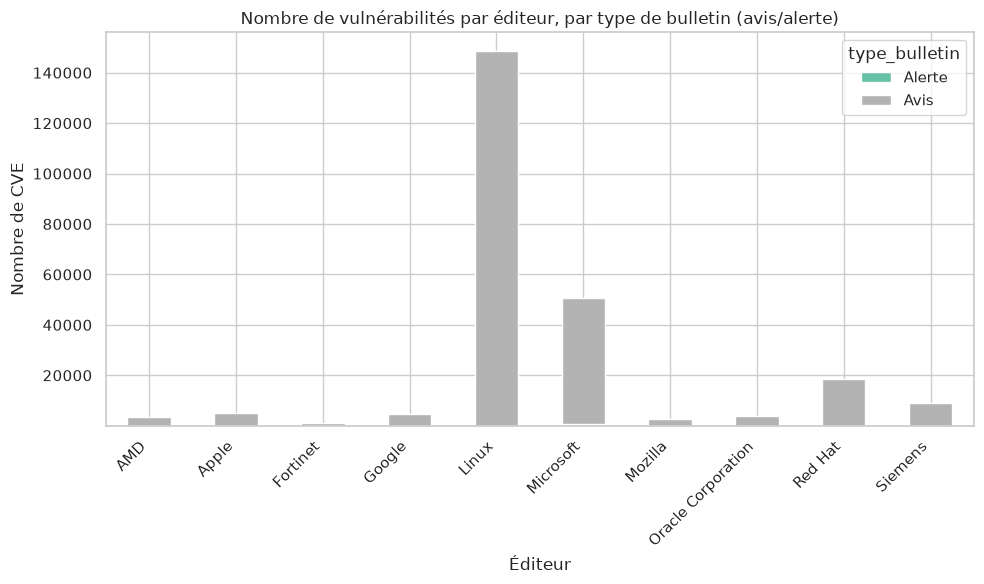

In [21]:
cross = df[df["editeur"].isin(top10_vendors)].groupby(["editeur", "type_bulletin"]).size().unstack(fill_value=0)
cross.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="Set2")
plt.title("Nombre de vulnérabilités par éditeur, par type de bulletin (avis/alerte)")
plt.xlabel("Éditeur")
plt.ylabel("Nombre de CVE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4. Préparation des données pour le Machine Learning

On construit un jeu de features numériques/catégorielles à partir des
colonnes enrichies (CVSS, CWE, EPSS, éditeur...). On élimine les lignes sans
score CVSS ou EPSS (CVE non trouvées dans MITRE/FIRST), nécessaires pour
les deux approches ML.


In [24]:
ml_df = df.dropna(subset=["cvss_score", "epss_score", "cwe"]).copy()
ml_df = ml_df.drop_duplicates(subset=["cve"])
print("Nombre de CVE exploitables pour le ML :", len(ml_df))
ml_df[["cve", "cvss_score", "base_severity", "cwe", "epss_score"]].head()


Nombre de CVE exploitables pour le ML : 23975


,cve,cvss_score,base_severity,cwe,epss_score
1,CVE-2022-35845,7.6,HIGH,CWE-78,0.03866
2,CVE-2022-39947,8.6,HIGH,CWE-78,0.01711
3,CVE-2022-41336,6.6,MEDIUM,CWE-79,0.00322
4,CVE-2022-45857,6.0,MEDIUM,CWE-286,0.00348
5,CVE-2021-35097,7.3,HIGH,Non disponible,0.00032


## 5. Modèle non supervisé : Clustering des vulnérabilités

Objectif : regrouper les CVE en clusters homogènes à partir de leur score
CVSS et de leur score EPSS, afin d'identifier des profils de risque
(ex : faible gravité/faible exploitation, forte gravité/forte exploitation...).

On utilise **KMeans**, avec une normalisation préalable des features et une
recherche du nombre de clusters via le score de silhouette.


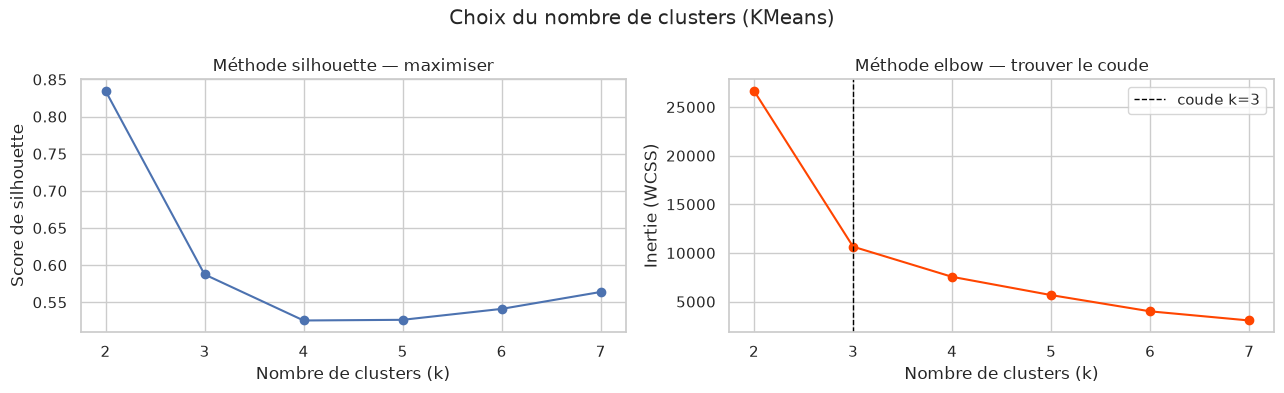

k retenu (méthode elbow) : 3
Silhouette k=2 : 0.8347 | k=3 : 0.5875
Inertie   k=2 : 26665 | k=3 : 10649 | k=4 : 7547


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = ml_df[["cvss_score", "epss_score"]].values
X_scaled = StandardScaler().fit_transform(X_cluster)

scores = {}
inertias = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores[k] = silhouette_score(X_scaled, labels)
    inertias[k] = km.inertia_

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Silhouette
axes[0].plot(list(scores.keys()), list(scores.values()), marker="o")
axes[0].set_xlabel("Nombre de clusters (k)")
axes[0].set_ylabel("Score de silhouette")
axes[0].set_title("Méthode silhouette - maximiser")

# Elbow
axes[1].plot(list(inertias.keys()), list(inertias.values()), marker="o", color="orangered")
axes[1].axvline(3, color="black", linestyle="--", linewidth=1, label="coude k=3")
axes[1].legend()
axes[1].set_xlabel("Nombre de clusters (k)")
axes[1].set_ylabel("Inertie (WCSS)")
axes[1].set_title("Méthode elbow - trouver le coude")

plt.suptitle("Choix du nombre de clusters (KMeans)")
plt.tight_layout()
plt.show()

# k=3 retenu d'après la méthode elbow (le coude se situe entre k=2 et k=3,
best_k = 3
print("k retenu (méthode elbow) :", best_k)
print(f"Silhouette k=2 : {scores[2]:.4f} | k=3 : {scores[3]:.4f}")
print(f"Inertie   k=2 : {inertias[2]:.0f} | k=3 : {inertias[3]:.0f} | k=4 : {inertias[4]:.0f}")

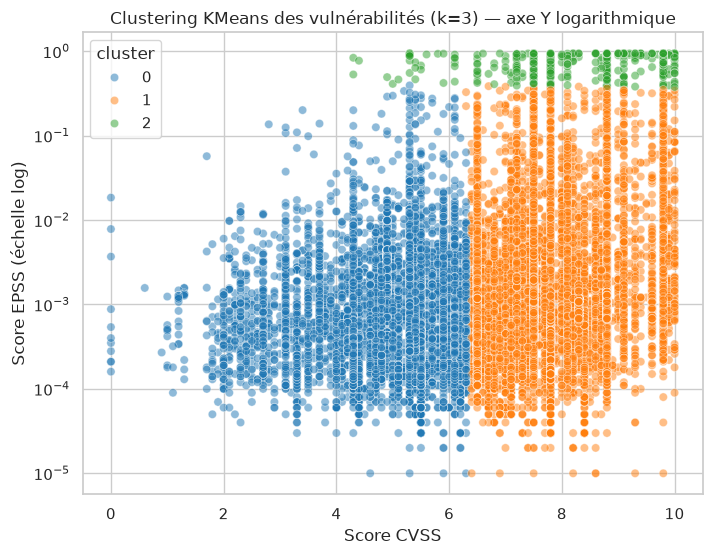

,cvss_score,epss_score
cluster,,
0,4.915670,0.003068
1,7.809212,0.009959
2,8.415952,0.754326


In [28]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
ml_df["cluster"] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=ml_df, x="cvss_score", y="epss_score", hue="cluster", palette="tab10", alpha=0.5)
plt.yscale("log")
plt.title(f"Clustering KMeans des vulnérabilités (k={best_k}) - axe Y logarithmique")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS (échelle log)")
plt.show()

ml_df.groupby("cluster")[["cvss_score", "epss_score"]].mean()

**Validation du modèle non supervisé** : le score de silhouette (calculé
ci-dessus pour plusieurs valeurs de k) mesure la cohérence interne des
clusters (entre -1 et 1, plus il est proche de 1 meilleure est la séparation).
Le k retenu est celui qui maximise ce score.


## 6. Modèle supervisé : Prédiction de la sévérité (Base Severity)

Objectif : prédire la catégorie de sévérité CVSS (`LOW`, `MEDIUM`, `HIGH`,
`CRITICAL`) d'une vulnérabilité à partir de l'EPSS et du type de faiblesse
(CWE), sans connaître directement le score CVSS.

On utilise le **KNN (K-Nearest Neighbors)** vu en TD3, avec sélection du
meilleur K par **validation croisée stratifiée** (5 folds) pour éviter le
biais lié au déséquilibre des classes.

In [61]:
ml_sup = ml_df.dropna(subset=["base_severity"]).copy()
ml_sup["base_severity"].value_counts()


base_severity
HIGH        10778
MEDIUM      10345
CRITICAL     1582
LOW          1259
NONE           11
Name: count, dtype: int64

In [62]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

ml_sup = ml_df.dropna(subset=["base_severity"]).copy()
ml_sup = ml_sup[ml_sup["cwe"] != "Non disponible"].copy()
ml_sup = ml_sup[ml_sup["base_severity"] != "NONE"].copy()
print("CVE exploitables pour le modèle supervisé :", len(ml_sup))
print(ml_sup["base_severity"].value_counts())

# Encodage du CWE (catégoriel) et de la cible
cwe_encoder = LabelEncoder()
ml_sup["cwe_encoded"] = cwe_encoder.fit_transform(ml_sup["cwe"].astype(str))
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(ml_sup["base_severity"])
X = ml_sup[["epss_score", "cwe_encoded"]]

# Sélection du meilleur K par validation croisée stratifiée (TD3)
k_values = [1, 3, 5, 7, 9, 11, 15]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for k in k_values:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k), X, y, cv=cv)
    cv_rows.append({"K": k, "moyenne": round(scores.mean(), 4), "std": round(scores.std(), 4)})
cv_results = pd.DataFrame(cv_rows)
print("\nValidation croisée (5 folds stratifiés) :")
print(cv_results.to_string(index=False))

best_k = int(cv_results.loc[cv_results["moyenne"].idxmax(), "K"])
print(f"\nMeilleur K : {best_k} (moyenne = {cv_results.loc[cv_results['K']==best_k, 'moyenne'].values[0]:.4f})")

# Évaluation finale avec le meilleur K sur un split train/test stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
clf = KNeighborsClassifier(n_neighbors=best_k)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f"\nAccuracy (K={best_k}) :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_, zero_division=0))

CVE exploitables pour le modèle supervisé : 14891
base_severity
HIGH        7222
MEDIUM      5960
CRITICAL     890
LOW          819
Name: count, dtype: int64

Validation croisée (5 folds stratifiés) :
 K  moyenne    std
 1   0.5622 0.0065
 3   0.5749 0.0092
 5   0.5946 0.0075
 7   0.6041 0.0064
 9   0.6013 0.0088
11   0.6077 0.0090
15   0.6108 0.0089

Meilleur K : 15 (moyenne = 0.6108)

Accuracy (K=15) : 0.6054257319366103
              precision    recall  f1-score   support

    CRITICAL       0.38      0.11      0.17       222
        HIGH       0.64      0.70      0.67      1806
         LOW       0.50      0.03      0.06       205
      MEDIUM       0.57      0.64      0.60      1490

    accuracy                           0.61      3723
   macro avg       0.52      0.37      0.37      3723
weighted avg       0.59      0.61      0.58      3723



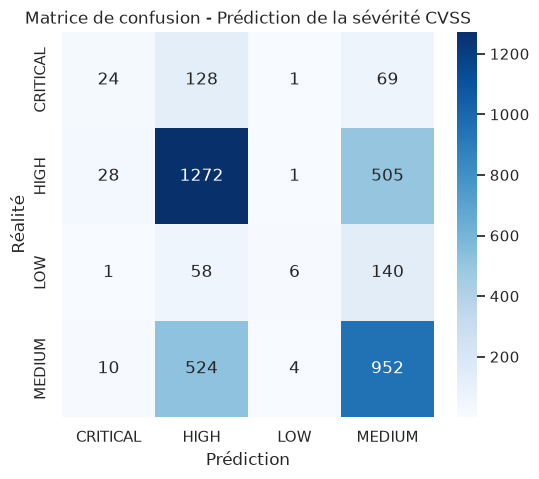

In [63]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_encoder.classes_, yticklabels=target_encoder.classes_)
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion - Prédiction de la sévérité CVSS")
plt.show()


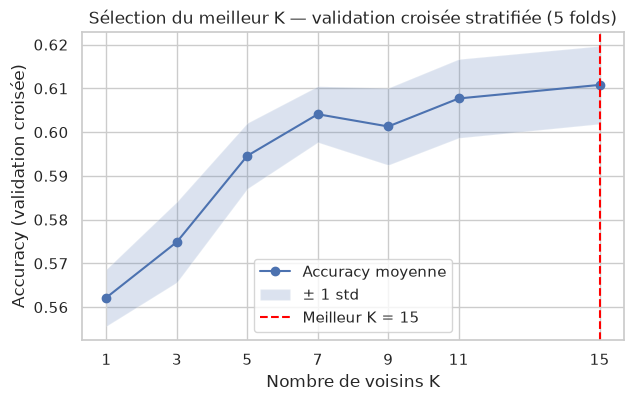

In [64]:
plt.figure(figsize=(7, 4))
plt.plot(cv_results["K"], cv_results["moyenne"], marker="o", label="Accuracy moyenne")
plt.fill_between(
    cv_results["K"],
    cv_results["moyenne"] - cv_results["std"],
    cv_results["moyenne"] + cv_results["std"],
    alpha=0.2, label="± 1 std"
)
plt.axvline(best_k, color="red", linestyle="--", label=f"Meilleur K = {best_k}")
plt.xlabel("Nombre de voisins K")
plt.ylabel("Accuracy (validation croisée)")
plt.title("Sélection du meilleur K - validation croisée stratifiée (5 folds)")
plt.legend()
plt.xticks(k_values)
plt.show()

**Validation du modèle supervisé** : le meilleur K est sélectionné par validation croisée stratifiée à 5 folds (comme vu en TD3), ce qui garantit que chaque fold contient la même proportion de classes malgré le déséquilibre HIGH/MEDIUM/CRITICAL/LOW. L'évaluation finale se fait sur un split train/test stratifié 75/25, avec accuracy, précision/rappel/F1 par classe (classification_report) et matrice de confusion.

## 7. Conclusion

### Données

Le corpus couvre **4 103 bulletins ANSSI** (2023–2026) soit **37 287 CVE uniques**
réparties sur **720 éditeurs** et **6 286 produits**.
Les avis représentent **99.7 %** des bulletins (283 754 vs 885 alertes) :
les exploitations actives confirmées restent rares dans le corpus ANSSI.

La principale limite structurelle est que **51 % des CVE n'ont pas de score CVSS**
dans MITRE - les CNA ne renseignent pas systématiquement ce champ,
ce qui réduit le jeu exploitable pour le ML à 48.8 % du corpus.

### Scores CVSS

Le score moyen est de **6.9** (médiane **7.5**) : l'ANSSI publie quasi exclusivement
des bulletins pour des failles sérieuses. Sur les CVE avec score disponible,
**54 % sont HIGH** et **37 % MEDIUM** - les cas LOW et CRITICAL sont minoritaires
(respectivement 4 % et 5 %), ce qui crée un déséquilibre de classes défavorable
au modèle supervisé.

### Scores EPSS

La médiane EPSS est de **0.00048** (0.05 %) : la quasi-totalité des CVE
référencées par l'ANSSI ne sont pas activement exploitées au moment de la
publication. Seules **3 094 CVE** (1.09 %) dépassent le seuil d'alerte EPSS ≥ 0.5,
et **7 010** (2.48 %) dépassent 0.1. Le module `alerting.py` ne déclenchera donc
des notifications que pour une fraction très restreinte du corpus - ce qui est
exactement le comportement attendu pour éviter la fatigue d'alerte.

### Modèle non supervisé - KMeans (k=3)

Le nombre de clusters est choisi par la **méthode elbow** : la courbe d'inertie
présente un coude net à k=3, après lequel le gain marginal devient négligeable.
La méthode silhouette favorisait k=2 (score 0.835) mais au prix d'une
sur-simplification - k=3 révèle une structure plus utile en pratique.

Les 3 clusters obtenus correspondent à des profils de risque interprétables :

| Cluster | CVSS moyen | EPSS moyen | Profil | Priorité |
|---|---|---|---|---|
| 0 (bleu) | **4.9** | 0.003 | Failles modérées, non exploitées | Surveiller |
| 1 (orange) | **7.8** | 0.010 | Failles graves, non exploitées | Patcher |
| 2 (vert) | **8.4** | **0.754** | Failles graves ET activement exploitées | **Urgence** |

Le cluster 2 est le plus critique : CVSS élevé **et** EPSS à 0.75 - ces CVE ont
3 chances sur 4 d'être exploitées dans les 30 prochains jours. C'est exactement
le groupe que le module `alerting.py` cible avec ses seuils `CVSS ≥ 9` ou `EPSS ≥ 0.5`.

### Modèle supervisé - KNN (K=15)

Avec seulement deux features (EPSS + CWE encodé), le KNN atteint une
**accuracy de 60.5 %** - correct pour une estimation de sévérité sans le score CVSS.

| Classe | F1-score | Interprétation |
|---|---|---|
| HIGH | **0.67** | Bien prédit - classe majoritaire |
| MEDIUM | **0.60** | Bien prédit - classe majoritaire |
| CRITICAL | 0.17 | Très mal prédit - confondu avec HIGH |
| LOW | 0.06 | Quasi invisible - confondu avec MEDIUM |

La validation croisée stratifiée montre une progression régulière de K=1 (0.562)
à K=15 (0.611) sans plateau net : le problème est intrinsèquement difficile
avec ces deux features. La limite principale est que CVSS et CWE ne sont pas
indépendants - prédire la sévérité sans le CVSS revient à reconstituer
l'information que le CVSS encode, avec un signal partiel.